In [1]:
#generating geometry
import numpy as np

Lx = float(input("Enter length in x-direction: "))
Ly = Lx/50
print("Beam aspect ratio =", Lx/Ly)

E = 210e9      # Young's modulus
nu = 0.3       # Poisson's ratio
t = 0.01       # thickness
bx = 0         #Body force along x
by = 0         #Body force along y direction


#defining mesh generating function

import matplotlib.pyplot as plt


# MESH GENERATION FUNCTION

def generate_mesh(Lx, Ly, nx, ny):

    dx = Lx / nx
    dy = Ly / ny

    nodes = []
    for j in range(ny + 1):
        for i in range(nx + 1):
            nodes.append([i * dx, j * dy])

    nodes = np.array(nodes)

    elements = []
    for j in range(ny):
        for i in range(nx):
            n1 = j*(nx+1) + i
            n2 = n1 + 1
            n3 = n2 + (nx+1)
            n4 = n1 + (nx+1)
            elements.append([n1, n2, n3, n4])

    elements = np.array(elements)

    return nodes, elements, dx, dy




#code for elemental stiffness matrix , body force vector , traction force vector


# Gauss Points
gauss_pts = [(-1/np.sqrt(3), -1/np.sqrt(3)),
             ( 1/np.sqrt(3), -1/np.sqrt(3)),
             ( 1/np.sqrt(3),  1/np.sqrt(3)),
             (-1/np.sqrt(3),  1/np.sqrt(3))]


def element_stiffness(coords, E, nu, t):
    
    # coords in array containing 4 coordinates of the element
    
    # Material matrix (plane stress)
    D = (E/(1 - nu**2)) * np.array([
        [1, nu, 0],
        [nu, 1, 0],
        [0, 0, (1-nu)/2]
    ])

    Ke = np.zeros((8,8))

    for xi, eta in gauss_pts:

        # Shape function derivatives
        dN_dxi = 0.25 * np.array([
            [-(1-eta), -(1-xi)],
            [ (1-eta), -(1+xi)],
            [ (1+eta),  (1+xi)],
            [-(1+eta),  (1-xi)]
        ])

        # Jacobian
        J = np.zeros((2,2))
        for i in range(4):
            J += np.outer(dN_dxi[i], coords[i])

        detJ = np.linalg.det(J)
        invJ = np.linalg.inv(J)

        # B matrix
        B = np.zeros((3,8))
        for i in range(4):
            dN = invJ @ dN_dxi[i]

            B[0,2*i]   = dN[0]
            B[1,2*i+1] = dN[1]
            B[2,2*i]   = dN[1]
            B[2,2*i+1] = dN[0]

        Ke += B.T @ D @ B * detJ * t

    return Ke 

# Body force vector
def element_body_force(coords, bx, by, t):
    Fe = np.zeros(8)

    for xi, eta in gauss_pts:

        # Shape functions
        N = 0.25 * np.array([
            (1-xi)*(1-eta),
            (1+xi)*(1-eta),
            (1+xi)*(1+eta),
            (1-xi)*(1+eta)
        ])

        # Derivatives for Jacobian
        dN_dxi = 0.25 * np.array([
            [-(1-eta), -(1-xi)],
            [ (1-eta), -(1+xi)],
            [ (1+eta),  (1+xi)],
            [-(1+eta),  (1-xi)]
        ])

        # Jacobian
        J = np.zeros((2,2))
        for i in range(4):
            J += np.outer(dN_dxi[i], coords[i])

        detJ = np.linalg.det(J)

        # Assemble
        for i in range(4):
            Fe[2*i]   += N[i] * bx * detJ * t
            Fe[2*i+1] += N[i] * by * detJ * t

    return Fe



# traction vector 
def element_traction(coords, edge, tx, ty, t):
    """
    edge: 0→(1-2), 1→(2-3), 2→(3-4), 3→(4-1)
    """

    Fe = np.zeros(8)

    # Edge node pairs
    edge_nodes = [(0,1), (1,2), (2,3), (3,0)]
    n1, n2 = edge_nodes[edge]

    x1, x2 = coords[n1], coords[n2]

    # Length of edge
    L = np.linalg.norm(x2 - x1)

    # 1D Gauss points
    gauss_1D = [-1/np.sqrt(3), 1/np.sqrt(3)]

    for xi in gauss_1D:

        # 1D shape functions
        N_edge = np.array([(1-xi)/2, (1+xi)/2])

        for i, node in enumerate([n1, n2]):
            Fe[2*node]   += N_edge[i] * tx * (L/2) * t
            Fe[2*node+1] += N_edge[i] * ty * (L/2) * t

    return Fe


#Solve
def solve_fem(nodes, elements):

    n_nodes = len(nodes)
    ndof = 2 * n_nodes

    K_global = np.zeros((ndof, ndof))
    F_global = np.zeros(ndof)

    # Assembly
    for e in range(len(elements)):

        node_ids = elements[e]
        coords = nodes[node_ids]

        Ke = element_stiffness(coords, E, nu, t)
        Fe = element_body_force(coords, bx, by, t)

        # traction on top edge
        y_coords = coords[:,1]
        if np.allclose(y_coords[2:], Ly):
            Fe += element_traction(coords, edge=2, tx=0, ty=-10000, t=t)

        # DOF mapping
        dof = []
        for n in node_ids:
            dof.extend([2*n, 2*n+1])

        # Assemble
        for i in range(8):
            for j in range(8):
                K_global[dof[i], dof[j]] += Ke[i, j]

        for i in range(8):
            F_global[dof[i]] += Fe[i]
        

    # Boundary condition (fix left edge)
    fixed_dof = []
    for i, (x, y) in enumerate(nodes):
        if np.isclose(x, 0):
            fixed_dof.extend([2*i, 2*i+1])

    free_dof = [i for i in range(ndof) if i not in fixed_dof]

    # Reduce system
    K_reduced = K_global[np.ix_(free_dof, free_dof)]
    F_reduced = F_global[free_dof]

    
    U = np.zeros(ndof)
    U[free_dof] = np.linalg.solve(K_reduced, F_reduced)

    return U , K_global
    
    

Beam aspect ratio = 50.0


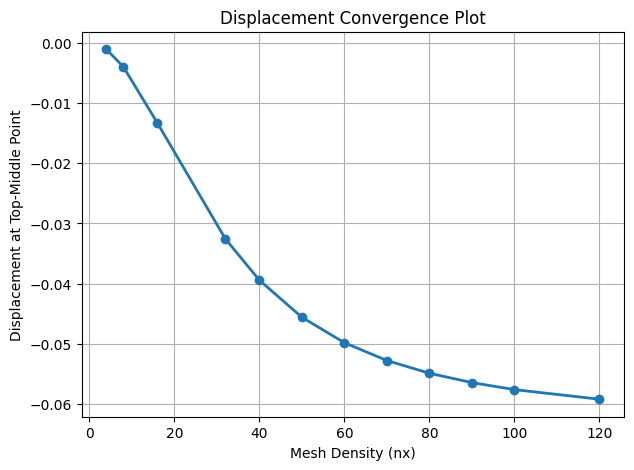

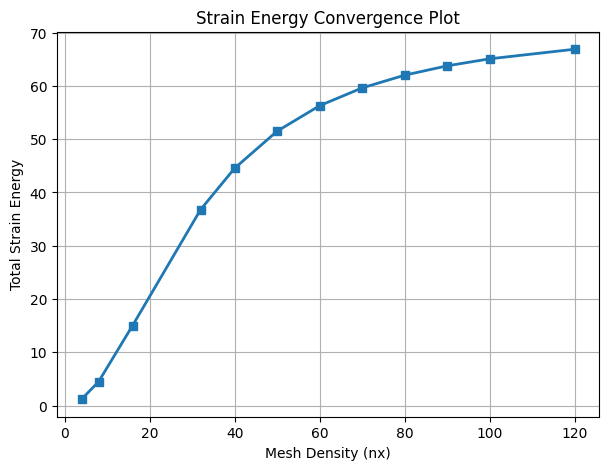

In [7]:
results_disp = []

results_energy = []

mesh_sizes = [4,8,16,32,40,50,60,70,80,90,100,120]

for n in mesh_sizes:

    nodes, elements, _, _ = generate_mesh(Lx, Ly, n, 10)

    # FEM solution
    U, K_global = solve_fem(nodes, elements)

    # Convert displacement vector to 1D
    U = np.array(U).flatten()

    # -------------------------------------------------
    # Displacement at top-middle point
    # -------------------------------------------------
    target_node = np.argmin(
        (nodes[:,0] - Lx/2)**2 +
        (nodes[:,1] - Ly)**2
    )

    uy = U[2*target_node + 1]

    results_disp.append(uy)

    # -------------------------------------------------
    # Total strain energy
    # -------------------------------------------------
    strain_energy = 0.5 * U @ K_global @ U

    results_energy.append(strain_energy)

# -----------------------------------------------------
# Displacement convergence plot
# -----------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(mesh_sizes, results_disp, 'o-', linewidth=2)

plt.xlabel("Mesh Density (nx)")

plt.ylabel("Displacement at Top-Middle Point")

plt.title("Displacement Convergence Plot")

plt.grid(True)

plt.show()

# -----------------------------------------------------
# Strain energy convergence plot
# -----------------------------------------------------

plt.figure(figsize=(7,5))

plt.plot(mesh_sizes, results_energy, 's-', linewidth=2)

plt.xlabel("Mesh Density (nx)")

plt.ylabel("Total Strain Energy")

plt.title("Strain Energy Convergence Plot")

plt.grid(True)

plt.show()

In [8]:
# For Nx=120 Displacement at bottom middle node

traction_y = -10000   # N/m^2
w = (traction_y) * t
I = t * Ly**3 / 12

A = t * Ly

G = E / (2*(1+nu))

k = 5/6

delta_EB = w * Lx**4 / (8 * E * I)
delta_T = (w * Lx**4)/(8*E*I) + (w * Lx**2)/(2*k*G*A)

target_node = np.argmin(
    (nodes[:,0] - Lx)**2 +
    (nodes[:,1] - Ly/2)**2
)
nodes, elements, _, _ = generate_mesh(Lx, Ly, 120, 10)
U , K_global = solve_fem(nodes, elements)
uy_fem = U[2*target_node + 1]


error_EB = abs((uy_fem - delta_EB)/delta_EB)*100

error_T = abs((uy_fem - delta_T)/delta_T)*100

print("FEM =", uy_fem)
print("Euler-Bernoulli =", delta_EB)
print("Timoshenko =", delta_T)

print("EB Error % =", error_EB)
print("Timoshenko Error % =", error_T)




FEM = -0.16715638520348391
Euler-Bernoulli = -0.17857142857142852
Timoshenko = -0.17864571428571424
EB Error % = 6.392424286048981
Timoshenko Error % = 6.431348844929493


In [5]:
U_EB = (w**2 * Lx**5) / (40 * E * I)
U_T = (w**2 * Lx**5)/(40*E*I) + (w**2 * Lx**3)/(6*k*G*A)
strain_energy_fem = 0.5 * U @ K_global @ U
error_EB = abs((strain_energy_fem - U_EB)/U_EB)*100

error_T = abs((strain_energy_fem - U_T)/U_T)*100
print( "Strain energy Fem" , strain_energy_fem)
print("Euler-Bernoulli:", U_EB)
print("Timoshenko:", U_T)

print("EB Error %:", error_EB)
print("Timoshenko Error %:", error_T)

Strain energy Fem 66.8674468558886
Euler-Bernoulli: 71.42857142857142
Timoshenko: 71.47809523809522
EB Error %: 6.3855744017559415
Timoshenko Error %: 6.450435433188925
